<div style="background-color:#1F4E79; padding:30px; border-radius:10px; margin-bottom:10px">
 <h1 style="color:white; margin:0; font-size:2em"> Pertemuan 9 – Data Cleaning</h1>
 <h2 style="color:#D6E4F0; margin:8px 0 0 0; font-weight:normal">Pengantar Sains Data</h2>
</div>

| | |
|---|---|
| **Dataset** | House Prices – Ames, Iowa (Kaggle) |
| **Tools** | Python · Pandas · NumPy · Scikit-learn · Matplotlib |
| **Prasyarat** | Pertemuan 8 – Exploratory Data Analysis |

---

### Tujuan Pembelajaran
Setelah menyelesaikan pertemuan ini, mahasiswa diharapkan mampu:
1. Mengidentifikasi berbagai jenis masalah kualitas data pada dataset nyata
2. Memilih dan menerapkan strategi penanganan *missing values* yang tepat
3. Mendeteksi dan menangani outlier menggunakan metode statistik
4. Menerapkan teknik normalisasi (min-max scaling) dan standarisasi (z-score)
5. Mengimplementasikan proses *data cleaning* menggunakan Pandas dan Scikit-learn
6. Merancang pipeline *data cleaning* yang komprehensif untuk dataset House Prices

> **Catatan:** Modul ini melanjutkan eksplorasi dataset yang sama dari Pertemuan 8 (EDA). 
> Pastikan file `train.csv` tersedia di direktori kerja Anda sebelum memulai.

## ️ Setup: Import Library dan Muat Dataset

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Pengaturan tampilan
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid')

# Muat dataset
df = pd.read_csv('data-cleaning-sample.csv')
print(f' Dataset berhasil dimuat')
print(f' Jumlah baris : {df.shape[0]:,}')
print(f' Jumlah kolom : {df.shape[1]:,}')
df.head(3)

 Dataset berhasil dimuat
 Jumlah baris : 1,460
 Jumlah kolom : 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.00,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.00,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


---
## 7.1 Jenis Masalah Kualitas Data

Data yang dikumpulkan dari dunia nyata hampir tidak pernah sempurna. Sebelum melakukan analisis atau membangun model machine learning, kita perlu memahami berbagai masalah kualitas data yang mungkin muncul.

Empat jenis masalah utama:
- **Missing Values** – nilai yang tidak tersedia
- **Duplikat** – baris yang muncul lebih dari sekali
- **Inkonsistensi Format** – representasi data yang tidak seragam
- **Outlier** – nilai yang jauh menyimpang dari sebagian besar data

### 7.1.1 Missing Values (Nilai Hilang)

*Missing values* adalah kondisi di mana satu atau lebih nilai pada kolom tertentu tidak tersedia, direpresentasikan sebagai `NaN` (Not a Number) di Pandas.

**Penyebab umum:**
- Data tidak dikumpulkan saat pencatatan awal (kolom opsional)
- Kesalahan sistem saat pengumpulan data
- Data memang tidak relevan (misal: kolom `PoolQC` kosong karena rumah tidak memiliki kolam renang)
- Penggabungan dataset dari sumber berbeda

> ️ **Penting:** Bedakan antara *"missing karena tidak ada"* vs *"missing karena lupa dicatat"*. Pemahaman konteks domain sangat penting sebelum menentukan strategi penanganan.

In [75]:
# ── Ringkasan missing values ───────────────────────────────────────────────
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(1)

missing_df = pd.DataFrame({
 'Jumlah Kosong' : missing_count,
 'Persen (%)' : missing_pct,
 'Tipe Data' : df.dtypes
})

missing_df = missing_df[missing_df['Jumlah Kosong'] > 0].sort_values('Persen (%)', ascending=False)
print(f'Kolom dengan missing values: {len(missing_df)} dari {df.shape[1]} kolom\n')
missing_df

Kolom dengan missing values: 19 dari 81 kolom



,Jumlah Kosong,Persen (%),Tipe Data
PoolQC,1453,99.50,object
MiscFeature,1406,96.30,object
Alley,1369,93.80,object
Fence,1179,80.80,object
MasVnrType,872,59.70,object
FireplaceQu,690,47.30,object
LotFrontage,259,17.70,float64
GarageType,81,5.50,object
GarageYrBlt,81,5.50,float64
GarageFinish,81,5.50,object


c:\Users\Nitro V\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


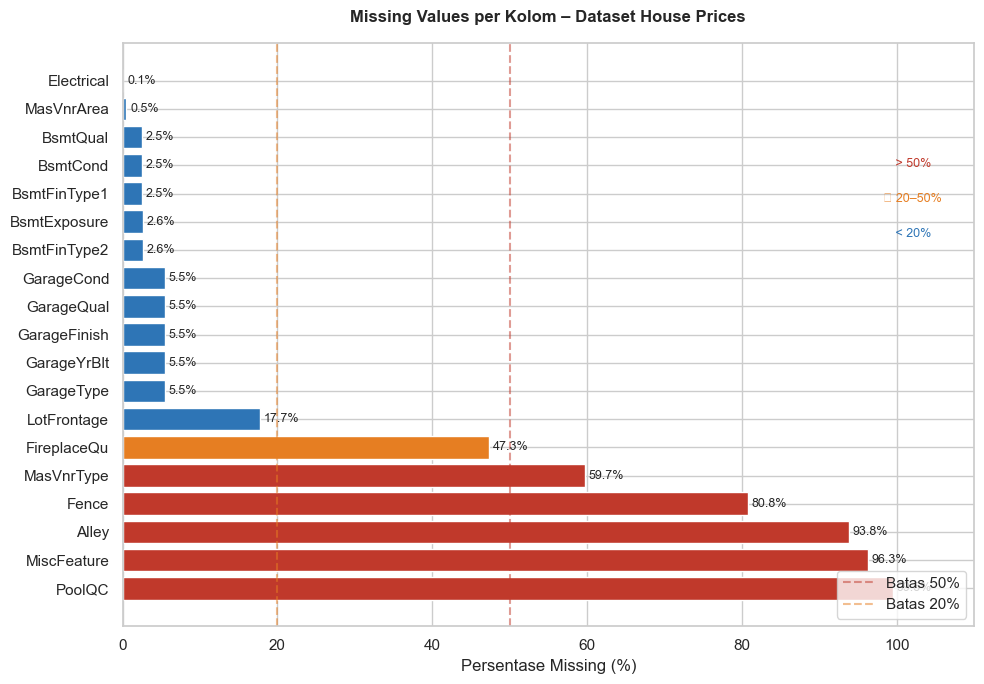

In [76]:
# ── Visualisasi missing values ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#C0392B' if p > 50 else '#E67E22' if p > 20 else '#2E75B6'
 for p in missing_df['Persen (%)']]

bars = ax.barh(missing_df.index, missing_df['Persen (%)'], color=colors, edgecolor='white')

for bar, pct in zip(bars, missing_df['Persen (%)']):
 ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
 f'{pct}%', va='center', fontsize=9)

ax.axvline(50, color='#C0392B', linestyle='--', alpha=0.5, label='Batas 50%')
ax.axvline(20, color='#E67E22', linestyle='--', alpha=0.5, label='Batas 20%')
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Missing Values per Kolom – Dataset House Prices', fontweight='bold', pad=15)
ax.legend(loc='lower right')
ax.set_xlim(0, 110)

# Tambahkan label kategori
fig.text(0.92, 0.75, ' > 50%', ha='center', color='#C0392B', fontsize=9)
fig.text(0.92, 0.70, '🟠 20–50%', ha='center', color='#E67E22', fontsize=9)
fig.text(0.92, 0.65, ' < 20%', ha='center', color='#2E75B6', fontsize=9)

plt.tight_layout()
plt.show()

In [77]:
# ── Kategorisasi missing values berdasarkan konteks domain ────────────────
# Kolom yang NaN-nya bermakna 'tidak ada fitur tersebut'
missing_meaning = {
 'Alley' : ('93.8%', 'Tidak ada akses gang – BUKAN data hilang'),
 'PoolQC' : ('99.5%', 'Rumah tidak memiliki kolam renang'),
 'MiscFeature' : ('96.3%', 'Tidak ada fitur tambahan khusus'),
 'Fence' : ('80.8%', 'Tidak ada pagar'),
 'FireplaceQu' : ('47.3%', 'Tidak ada perapian'),
 'GarageType' : ('5.5%', 'Rumah tidak memiliki garasi'),
 'BsmtQual' : ('2.5%', 'Tidak ada basement'),
 'MasVnrType' : ('59.7%', 'Tidak ada veneer tembok batu'),
}
# Kolom yang NaN-nya benar-benar data hilang
truly_missing = {
 'LotFrontage' : ('17.7%', 'Data panjang jalan depan tidak tercatat'),
 'MasVnrArea' : ('0.5%', 'Luas veneer tidak tercatat'),
 'GarageYrBlt' : ('5.5%', 'Tahun garasi dibangun tidak tercatat'),
 'Electrical' : ('0.07%', 'Tipe listrik tidak tercatat (1 baris)'),
}

print('=' * 65)
print('KATEGORI 1: NaN bermakna "tidak ada" (bukan error data)')
print('=' * 65)
for col, (pct, desc) in missing_meaning.items():
 print(f' {col:<15} {pct:>6} → {desc}')

print()
print('=' * 65)
print('KATEGORI 2: Data benar-benar hilang (perlu imputation)')
print('=' * 65)
for col, (pct, desc) in truly_missing.items():
 print(f' {col:<15} {pct:>6} → {desc}')

KATEGORI 1: NaN bermakna "tidak ada" (bukan error data)
 Alley            93.8% → Tidak ada akses gang – BUKAN data hilang
 PoolQC           99.5% → Rumah tidak memiliki kolam renang
 MiscFeature      96.3% → Tidak ada fitur tambahan khusus
 Fence            80.8% → Tidak ada pagar
 FireplaceQu      47.3% → Tidak ada perapian
 GarageType        5.5% → Rumah tidak memiliki garasi
 BsmtQual          2.5% → Tidak ada basement
 MasVnrType       59.7% → Tidak ada veneer tembok batu

KATEGORI 2: Data benar-benar hilang (perlu imputation)
 LotFrontage      17.7% → Data panjang jalan depan tidak tercatat
 MasVnrArea        0.5% → Luas veneer tidak tercatat
 GarageYrBlt       5.5% → Tahun garasi dibangun tidak tercatat
 Electrical       0.07% → Tipe listrik tidak tercatat (1 baris)


### 7.1.2 Duplikat

In [78]:
# ── Deteksi duplikat ───────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f'Jumlah baris duplikat: {n_dup}')

if n_dup > 0:
 print('\nBaris yang duplikat:')
 display(df[df.duplicated(keep=False)])
 
 # Cara menghapus duplikat
 df_no_dup = df.drop_duplicates()
 print(f'Shape setelah drop duplikat: {df_no_dup.shape}')
else:
 print(' Tidak ditemukan baris duplikat pada dataset ini.')

Jumlah baris duplikat: 0
 Tidak ditemukan baris duplikat pada dataset ini.


### 7.1.3 Outlier

Outlier adalah nilai yang jauh menyimpang dari sebagian besar data lainnya. Dapat disebabkan oleh:
- Kesalahan pengukuran / input
- Observasi yang sah namun ekstrem (rumah mewah)

**Metode deteksi:**
- **IQR Method**: nilai di luar `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`
- **Z-Score Method**: nilai dengan `|z| > 3`

In [79]:
# ── Deteksi outlier dengan metode IQR ─────────────────────────────────────
def detect_outliers_iqr(df, column):
 Q1 = df[column].quantile(0.25)
 Q3 = df[column].quantile(0.75)
 IQR = Q3 - Q1
 lower = Q1 - 1.5 * IQR
 upper = Q3 + 1.5 * IQR
 n_outliers = ((df[column] < lower) | (df[column] > upper)).sum()
 return {
 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
 'Batas Bawah': lower, 'Batas Atas': upper,
 'Jml Outlier': n_outliers
 }

key_cols = ['SalePrice', 'GrLivArea', 'LotArea', 'GarageArea', 'TotalBsmtSF']
iqr_results = pd.DataFrame({col: detect_outliers_iqr(df, col) for col in key_cols}).T
iqr_results = iqr_results.astype(float).round(0)
print('Ringkasan Outlier (Metode IQR):')
iqr_results

Ringkasan Outlier (Metode IQR):


,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jml Outlier
SalePrice,129975.00,214000.00,84025.00,3938.00,340038.00,61.00
GrLivArea,1130.00,1777.00,647.00,159.00,2748.00,31.00
LotArea,7554.00,11602.00,4048.00,1482.00,17674.00,69.00
GarageArea,334.00,576.00,242.00,-28.00,938.00,21.00
TotalBsmtSF,796.00,1298.00,502.00,42.00,2052.00,61.00


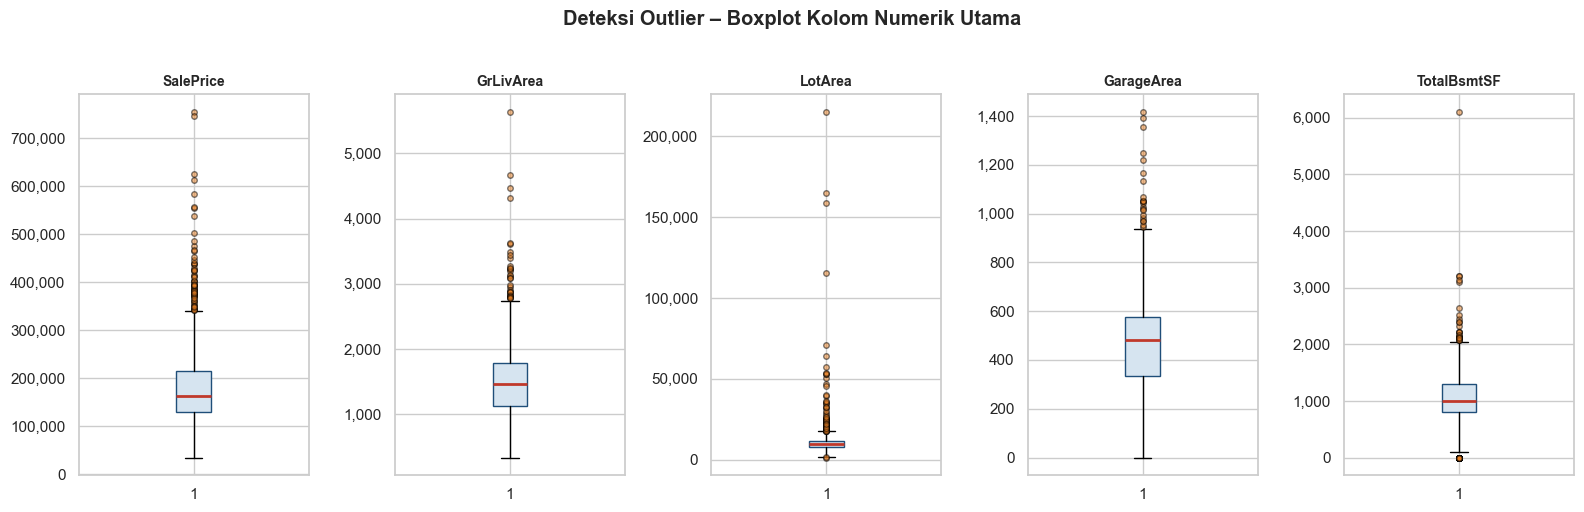

In [80]:
# ── Visualisasi outlier dengan boxplot ────────────────────────────────────
fig, axes = plt.subplots(1, len(key_cols), figsize=(16, 5))

for ax, col in zip(axes, key_cols):
 ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
 boxprops=dict(facecolor='#D6E4F0', color='#1F4E79'),
 medianprops=dict(color='#C0392B', linewidth=2),
 flierprops=dict(marker='o', markerfacecolor='#E67E22', markersize=4, alpha=0.5))
 ax.set_title(col, fontsize=10, fontweight='bold')
 ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Deteksi Outlier – Boxplot Kolom Numerik Utama', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [81]:
# ── Deteksi outlier dengan Z-Score ─────────────────────────────────────────
z_scores = np.abs(stats.zscore(df[key_cols].dropna()))
outliers_z = (z_scores > 3).sum()
print('Jumlah Outlier per Kolom (Metode Z-Score, |z| > 3):')
for col, n in zip(key_cols, outliers_z):
 print(f' {col:<15}: {n} outlier')

Jumlah Outlier per Kolom (Metode Z-Score, |z| > 3):
 SalePrice      : 22 outlier
 GrLivArea      : 16 outlier
 LotArea        : 13 outlier
 GarageArea     : 7 outlier
 TotalBsmtSF    : 10 outlier


---
## 7.2 Strategi Penanganan Missing Values

Terdapat dua pendekatan utama: **drop** (menghapus) atau **imputation** (mengisi). Pilihan strategi bergantung pada:
- Jumlah data yang hilang
- Pola ketidakhadiran data (apakah acak atau berpola)
- Tujuan analisis

| Strategi | Kapan Digunakan | Risiko |
|---|---|---|
| **Drop kolom** | Missing > 60–70%, atau kolom tidak informatif | Kehilangan fitur potensial |
| **Drop baris** | Missing < 5%, acak | Dataset mengecil |
| **Constant fill** | NaN bermakna 'tidak ada' | Tidak ada |
| **Mean/Median fill** | Numerik, data hilang acak | Bias distribusi |
| **Mode fill** | Kategorikal | Bias ke kategori dominan |

### 7.2.1 Drop

In [82]:
# ── Drop kolom dengan missing sangat tinggi (> 80%) ────────────────────────
high_missing_cols = missing_df[missing_df['Persen (%)'] > 80].index.tolist()
print(f'Kolom yang akan di-drop (missing > 80%): {high_missing_cols}')

df_demo_drop = df.drop(columns=high_missing_cols)
print(f'Shape sebelum drop kolom : {df.shape}')
print(f'Shape setelah drop kolom : {df_demo_drop.shape}')

Kolom yang akan di-drop (missing > 80%): ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
Shape sebelum drop kolom : (1460, 81)
Shape setelah drop kolom : (1460, 77)


In [83]:
# ── Demonstrasi dropna() ───────────────────────────────────────────────────
# PERHATIAN: dropna() tanpa parameter bisa menghapus sangat banyak baris!
df_dropna_all = df.dropna() # hapus baris yang memiliki APAPUN NaN
print(f'Shape setelah dropna() penuh : {df_dropna_all.shape}')
print(f'Baris yang terhapus : {df.shape[0] - df_dropna_all.shape[0]}')
print()

# Lebih bijak: drop hanya baris yang missing di kolom tertentu
df_dropna_specific = df.dropna(subset=['Electrical']) # hanya 1 baris
print(f'Shape setelah dropna(Electrical): {df_dropna_specific.shape}')
print('→ Hanya 1 baris yang dihapus, lebih aman.')

Shape setelah dropna() penuh : (0, 81)
Baris yang terhapus : 1460

Shape setelah dropna(Electrical): (1459, 81)
→ Hanya 1 baris yang dihapus, lebih aman.


### 7.2.2 Imputation (Pengisian)

In [84]:
# ── Terapkan strategi imputation pada dataset ──────────────────────────────
df_clean = df.copy()

# ── STRATEGI 1: Konstanta bermakna untuk kolom kategorikal ────────────────
# Kolom yang NaN-nya berarti 'tidak ada fitur tersebut'
fill_none = {
 'Alley' : 'NoAlley',
 'PoolQC' : 'NoPool',
 'Fence' : 'NoFence',
 'MiscFeature' : 'None',
 'FireplaceQu' : 'NoFireplace',
 'GarageType' : 'NoGarage',
 'GarageFinish': 'NoGarage',
 'GarageQual' : 'NoGarage',
 'GarageCond' : 'NoGarage',
 'BsmtQual' : 'NoBsmt',
 'BsmtCond' : 'NoBsmt',
 'BsmtExposure': 'NoBsmt',
 'BsmtFinType1': 'NoBsmt',
 'BsmtFinType2': 'NoBsmt',
 'MasVnrType' : 'None',
}
for col, val in fill_none.items():
 df_clean[col] = df_clean[col].fillna(val)
print(f' Strategi 1 (konstanta): {len(fill_none)} kolom diisi')

# ── STRATEGI 2: Median untuk numerik (robust terhadap outlier) ─────────────
median_lot = df_clean['LotFrontage'].median()
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(median_lot)
print(f' Strategi 2 (median): LotFrontage diisi dengan median = {median_lot:.1f} feet')

# MasVnrArea: isi dengan 0 (tidak ada veneer = 0 area)
df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)
print(f' Strategi 2 (konstanta numerik): MasVnrArea diisi dengan 0')

# ── STRATEGI 3: Isi GarageYrBlt dengan YearBuilt ──────────────────────────
df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(df_clean['YearBuilt'])
print(f' Strategi 3 (kolom lain): GarageYrBlt diisi dengan YearBuilt')

# ── STRATEGI 4: Mode untuk kategorikal (1 nilai missing) ──────────────────
mode_elec = df_clean['Electrical'].mode()[0]
df_clean['Electrical'] = df_clean['Electrical'].fillna(mode_elec)
print(f' Strategi 4 (mode): Electrical diisi dengan "{mode_elec}"')

# ── Verifikasi ─────────────────────────────────────────────────────────────
sisa = df_clean.isnull().sum().sum()
print(f'\n Total missing values tersisa: {sisa}')

 Strategi 1 (konstanta): 15 kolom diisi
 Strategi 2 (median): LotFrontage diisi dengan median = 69.0 feet
 Strategi 2 (konstanta numerik): MasVnrArea diisi dengan 0
 Strategi 3 (kolom lain): GarageYrBlt diisi dengan YearBuilt
 Strategi 4 (mode): Electrical diisi dengan "SBrkr"

 Total missing values tersisa: 0


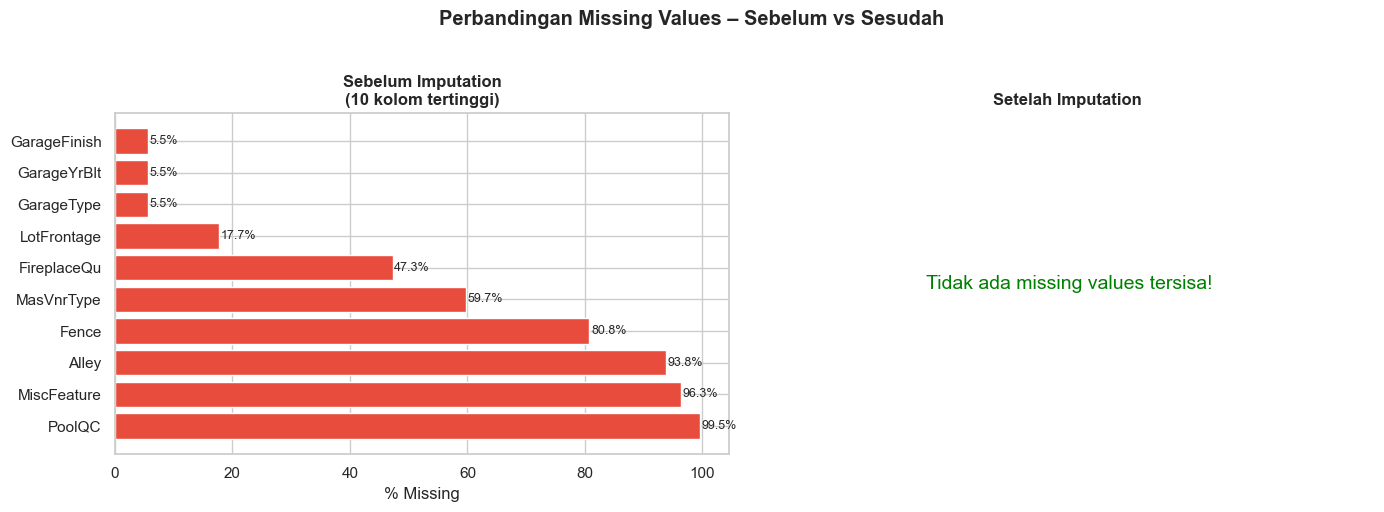

In [85]:
# ── Visualisasi perbandingan sebelum vs sesudah imputation ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum
miss_before = (df.isnull().sum() / len(df) * 100)
miss_before = miss_before[miss_before > 0].sort_values(ascending=False).head(10)
axes[0].barh(miss_before.index, miss_before.values, color='#E74C3C')
axes[0].set_title('Sebelum Imputation\n(10 kolom tertinggi)', fontweight='bold')
axes[0].set_xlabel('% Missing')
for i, v in enumerate(miss_before.values):
 axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# Sesudah
miss_after = (df_clean.isnull().sum() / len(df_clean) * 100)
miss_after = miss_after[miss_after > 0].sort_values(ascending=False)
if len(miss_after) == 0:
 axes[1].text(0.5, 0.5, ' Tidak ada missing values tersisa!',
 ha='center', va='center', fontsize=14, color='green',
 transform=axes[1].transAxes)
 axes[1].axis('off')
else:
 axes[1].barh(miss_after.index, miss_after.values, color='#27AE60')
axes[1].set_title('Setelah Imputation', fontweight='bold')

plt.suptitle('Perbandingan Missing Values – Sebelum vs Sesudah', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7.3 Strategi Penanganan Outlier

Setelah menangani missing values, kita perlu memutuskan cara menangani outlier. Tiga strategi utama:

| Strategi | Deskripsi | Kapan Digunakan |
|---|---|---|
| **Remove** | Hapus baris yang mengandung outlier | Outlier akibat error data |
| **Cap (Winsorize)** | Batasi nilai ke persentil tertentu | Outlier valid namun terlalu ekstrem |
| **Transform** | Terapkan transformasi matematis (log, sqrt) | Data skewed, untuk model linear |

### 7.3.1 Remove

Kandidat outlier (GrLivArea > 4000):
      GrLivArea  SalePrice Neighborhood
523        4676     184750      Edwards
691        4316     755000      NoRidge
1182       4476     745000      NoRidge
1298       5642     160000      Edwards


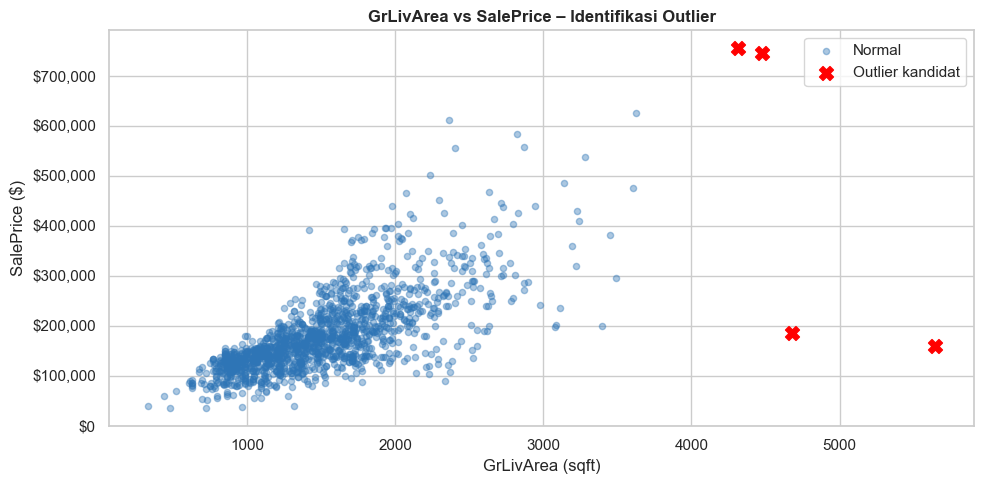

In [86]:
# ── Identifikasi outlier ekstrem pada GrLivArea ────────────────────────────
# Rumah dengan luas > 4000 sqft namun harga sangat rendah → kemungkinan error
suspected_outliers = df_clean[df_clean['GrLivArea'] > 4000][['GrLivArea', 'SalePrice', 'Neighborhood']]
print('Kandidat outlier (GrLivArea > 4000):')
print(suspected_outliers)

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_clean['GrLivArea'], df_clean['SalePrice'],
 alpha=0.4, color='#2E75B6', s=20, label='Normal')
ax.scatter(suspected_outliers['GrLivArea'], suspected_outliers['SalePrice'],
 color='red', s=100, marker='X', zorder=5, label='Outlier kandidat')
ax.set_xlabel('GrLivArea (sqft)')
ax.set_ylabel('SalePrice ($)')
ax.set_title('GrLivArea vs SalePrice – Identifikasi Outlier', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

In [87]:
# ── Remove outlier ────────────────────────────────────────────────────────
print(f'Shape sebelum remove outlier: {df_clean.shape}')
df_clean = df_clean[df_clean['GrLivArea'] <= 4000]
print(f'Shape setelah remove outlier: {df_clean.shape}')
print(f'Baris yang dihapus : {1460 - len(df_clean)}')

Shape sebelum remove outlier: (1460, 81)
Shape setelah remove outlier: (1456, 81)
Baris yang dihapus : 4


### 7.3.2 Cap / Winsorization

LotArea asli – Min:      1,300 Max:    215,245
LotArea capped – Min:      1,680 Max:     35,415

Batas capping: P1 = 1,680 | P99 = 35,415


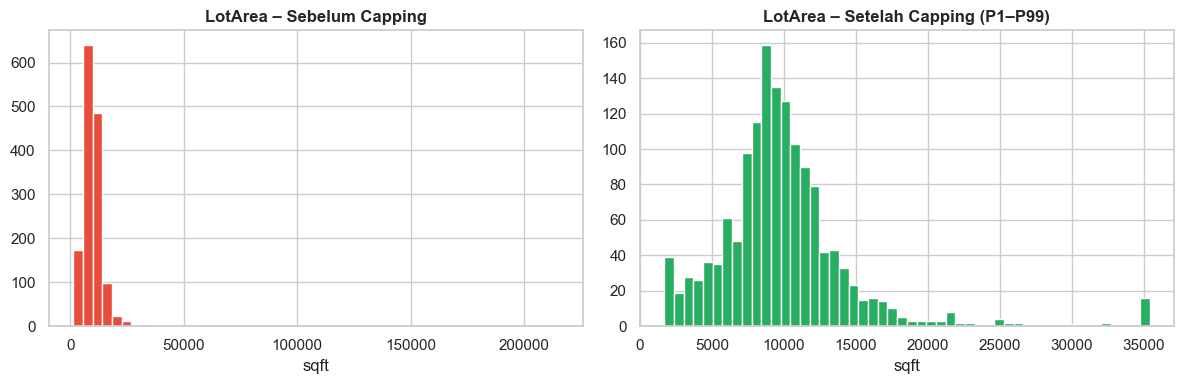

In [88]:
# ── Capping LotArea pada persentil ke-1 dan ke-99 ─────────────────────────
p1 = df_clean['LotArea'].quantile(0.01)
p99 = df_clean['LotArea'].quantile(0.99)

print(f'LotArea asli – Min: {df_clean["LotArea"].min():>10,.0f} Max: {df_clean["LotArea"].max():>10,.0f}')
df_clean['LotArea'] = df_clean['LotArea'].clip(lower=p1, upper=p99)
print(f'LotArea capped – Min: {df_clean["LotArea"].min():>10,.0f} Max: {df_clean["LotArea"].max():>10,.0f}')
print(f'\nBatas capping: P1 = {p1:,.0f} | P99 = {p99:,.0f}')

# Visualisasi efek capping
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['LotArea'].hist(bins=50, ax=axes[0], color='#E74C3C', edgecolor='white')
axes[0].set_title('LotArea – Sebelum Capping', fontweight='bold')
axes[0].set_xlabel('sqft')

df_clean['LotArea'].hist(bins=50, ax=axes[1], color='#27AE60', edgecolor='white')
axes[1].set_title('LotArea – Setelah Capping (P1–P99)', fontweight='bold')
axes[1].set_xlabel('sqft')

plt.tight_layout()
plt.show()

### 7.3.3 Transform (Log Transformation)

In [89]:
# ── Log transformation pada SalePrice ─────────────────────────────────────
# np.log1p(x) = log(1 + x) → aman untuk nilai 0
df_clean['SalePrice_log'] = np.log1p(df_clean['SalePrice'])

print('Statistik SalePrice (Asli):')
print(df_clean['SalePrice'].describe().round(0))
print()
print('Statistik SalePrice setelah Log Transform:')
print(df_clean['SalePrice_log'].describe().round(4))

# Hitung skewness
sk_before = df_clean['SalePrice'].skew()
sk_after = df_clean['SalePrice_log'].skew()
print(f'\nSkewness sebelum transform : {sk_before:.4f}')
print(f'Skewness setelah transform : {sk_after:.4f}')
print(f'(Nilai mendekati 0 = lebih simetris)')

Statistik SalePrice (Asli):
count     1456.00
mean    180151.00
std      76697.00
min      34900.00
25%     129900.00
50%     163000.00
75%     214000.00
max     625000.00
Name: SalePrice, dtype: float64

Statistik SalePrice setelah Log Transform:
count   1456.00
mean      12.02
std        0.40
min       10.46
25%       11.77
50%       12.00
75%       12.27
max       13.35
Name: SalePrice_log, dtype: float64

Skewness sebelum transform : 1.5660
Skewness setelah transform : 0.0655
(Nilai mendekati 0 = lebih simetris)


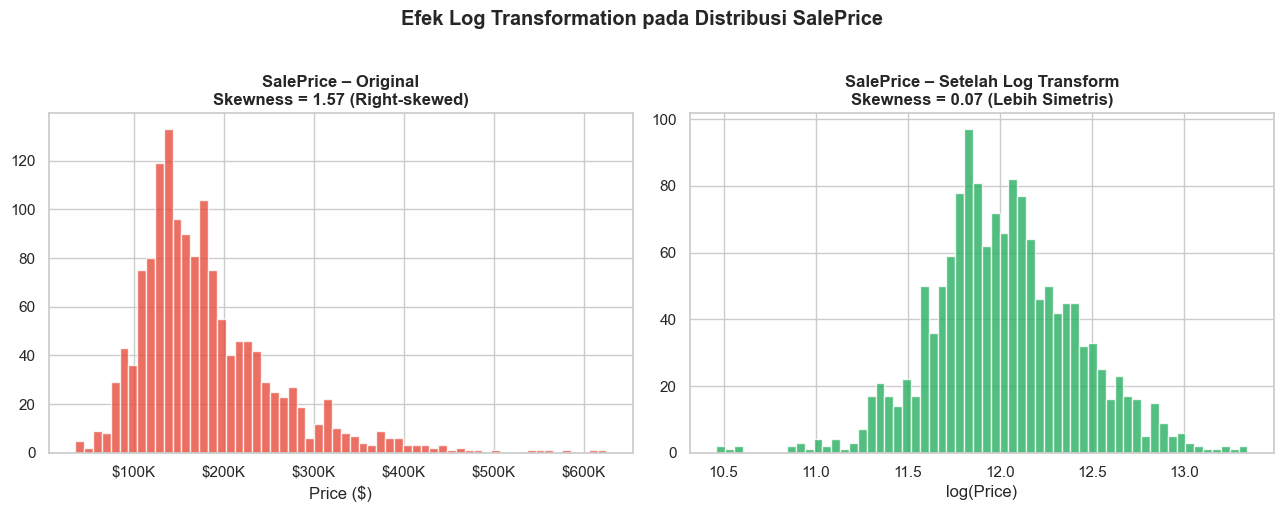

In [90]:
# ── Visualisasi distribusi sebelum dan sesudah log transform ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sebelum
axes[0].hist(df_clean['SalePrice'], bins=60, color='#E74C3C', edgecolor='white', alpha=0.8)
axes[0].set_title(f'SalePrice – Original\nSkewness = {sk_before:.2f} (Right-skewed)', fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Sesudah
axes[1].hist(df_clean['SalePrice_log'], bins=60, color='#27AE60', edgecolor='white', alpha=0.8)
axes[1].set_title(f'SalePrice – Setelah Log Transform\nSkewness = {sk_after:.2f} (Lebih Simetris)', fontweight='bold')
axes[1].set_xlabel('log(Price)')

plt.suptitle('Efek Log Transformation pada Distribusi SalePrice', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7.4 Normalisasi dan Standarisasi

Banyak algoritma ML sensitif terhadap perbedaan skala antar fitur. Kita perlu memastikan fitur numerik berada dalam skala yang sebanding.

### 7.4.1 Min-Max Scaling (Normalisasi)

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

- Output: rentang **[0, 1]**
- Sensitif terhadap outlier
- Cocok untuk: Neural Network, KNN

### 7.4.2 Z-Score Standardization (Standarisasi)

$$X_{std} = \frac{X - \mu}{\sigma}$$

- Output: mean ≈ 0, std ≈ 1
- Lebih robust terhadap outlier
- Cocok untuk: Regresi Linear, PCA, SVM

In [91]:
# ── Pilih kolom numerik untuk scaling ─────────────────────────────────────
num_features = ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'GarageArea', 'LotFrontage']

print('Statistik SEBELUM scaling:')
display(df_clean[num_features].describe().loc[['min', 'max', 'mean', 'std']].round(1))

Statistik SEBELUM scaling:


,GrLivArea,LotArea,TotalBsmtSF,GarageArea,LotFrontage
min,334.00,1680.00,0.00,0.00,21.00
max,3627.00,35415.20,3206.00,1390.00,313.00
mean,1506.50,9993.30,1050.70,471.60,69.60
std,496.80,4845.00,412.20,212.00,20.90


In [92]:
# ── Min-Max Scaling ───────────────────────────────────────────────────────
scaler_mm = MinMaxScaler()
df_minmax = pd.DataFrame(
 scaler_mm.fit_transform(df_clean[num_features]),
 columns=num_features
)

print('Statistik SETELAH Min-Max Scaling:')
display(df_minmax.describe().loc[['min', 'max', 'mean', 'std']].round(4))
print('→ Semua nilai berada dalam rentang [0, 1]')

Statistik SETELAH Min-Max Scaling:


,GrLivArea,LotArea,TotalBsmtSF,GarageArea,LotFrontage
min,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00
mean,0.36,0.25,0.33,0.34,0.17
std,0.15,0.14,0.13,0.15,0.07


→ Semua nilai berada dalam rentang [0, 1]


In [93]:
# ── Z-Score Standardization ───────────────────────────────────────────────
scaler_std = StandardScaler()
df_standardized = pd.DataFrame(
 scaler_std.fit_transform(df_clean[num_features]),
 columns=num_features
)

print('Statistik SETELAH Standarisasi (Z-Score):')
display(df_standardized.describe().loc[['min', 'max', 'mean', 'std']].round(4))
print('→ Mean ≈ 0, Std ≈ 1 untuk semua kolom')

Statistik SETELAH Standarisasi (Z-Score):


,GrLivArea,LotArea,TotalBsmtSF,GarageArea,LotFrontage
min,-2.36,-1.72,-2.55,-2.23,-2.32
max,4.27,5.25,5.23,4.33,11.65
mean,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00


→ Mean ≈ 0, Std ≈ 1 untuk semua kolom


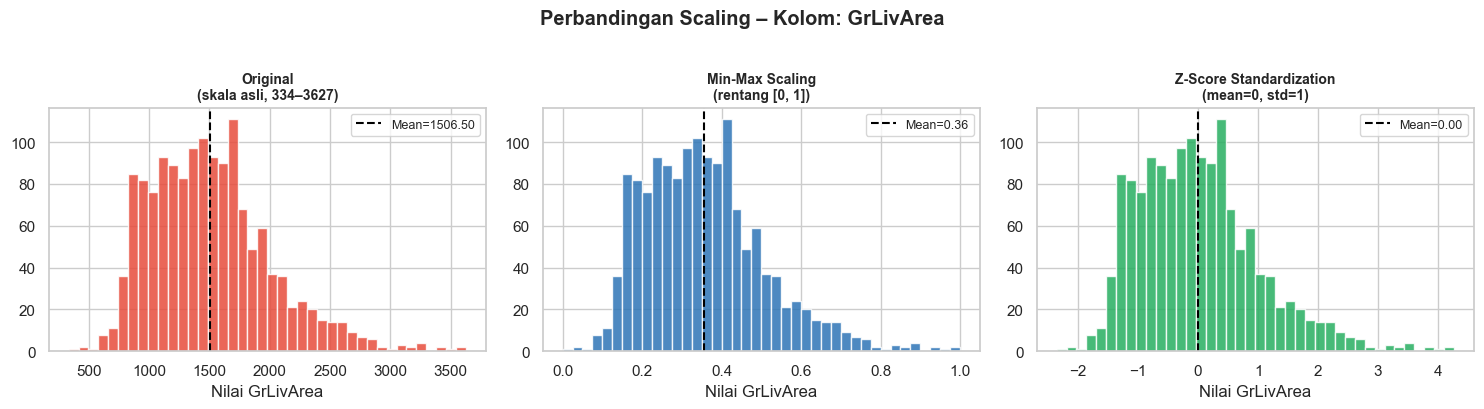

In [94]:
# ── Visualisasi perbandingan tiga kondisi: asli, min-max, z-score ──────────
col_demo = 'GrLivArea'
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

data_dict = {
 f'Original\n(skala asli, {df_clean[col_demo].min():.0f}–{df_clean[col_demo].max():.0f})': df_clean[col_demo],
 'Min-Max Scaling\n(rentang [0, 1])': df_minmax[col_demo],
 'Z-Score Standardization\n(mean=0, std=1)': df_standardized[col_demo],
}
colors_demo = ['#E74C3C', '#2E75B6', '#27AE60']

for ax, (title, data), color in zip(axes, data_dict.items(), colors_demo):
 ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
 ax.set_title(title, fontweight='bold', fontsize=10)
 ax.set_xlabel(f'Nilai {col_demo}')
 ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.2f}')
 ax.legend(fontsize=9)

plt.suptitle(f'Perbandingan Scaling – Kolom: {col_demo}', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [95]:
# ── Contoh interpretasi Z-Score ────────────────────────────────────────────
mean_gr = df_clean['GrLivArea'].mean()
std_gr = df_clean['GrLivArea'].std()

contoh_values = [1000, 1710, 2500, 4000]
print('Contoh Interpretasi Z-Score untuk GrLivArea:')
print(f' Mean GrLivArea = {mean_gr:.0f} sqft')
print(f' Std GrLivArea = {std_gr:.0f} sqft')
print()
print(f' {"Nilai (sqft)":>12} {"Z-Score":>10} Interpretasi')
print(f' {"-"*50}')
for v in contoh_values:
 z = (v - mean_gr) / std_gr
 if z < -1.5:
  interp = '← Jauh di bawah rata-rata'
 elif z < -0.5:
  interp = '← Di bawah rata-rata'
 elif z < 0.5:
  interp = '← Sekitar rata-rata'
 elif z < 1.5:
  interp = '← Di atas rata-rata'
 else:
  interp = '← Jauh di atas rata-rata'
 print(f' {v:>12,.0f} {z:>+10.3f} {interp}')

Contoh Interpretasi Z-Score untuk GrLivArea:
 Mean GrLivArea = 1507 sqft
 Std GrLivArea = 497 sqft

 Nilai (sqft)    Z-Score Interpretasi
 --------------------------------------------------
        1,000     -1.019 ← Di bawah rata-rata
        1,710     +0.410 ← Sekitar rata-rata
        2,500     +2.000 ← Jauh di atas rata-rata
        4,000     +5.019 ← Jauh di atas rata-rata


---
## 7.5 Kapan dan Mengapa Transformasi Data Diperlukan

### Alasan Utama Transformasi Diperlukan:

1. **Algoritma sensitif terhadap skala** – fitur berskala besar mendominasi fitur berskala kecil
2. **Konvergensi lebih cepat** – gradient descent konvergen lebih stabil dengan data ternormalisasi 
3. **Asumsi distribusi normal** – beberapa model mengasumsikan distribusi Gaussian
4. **Interpretabilitas** – z-score memungkinkan perbandingan lintas fitur

### Panduan Pemilihan Transformasi:

| Kondisi | Transformasi Disarankan | Algoritma yang Diuntungkan |
|---|---|---|
| Data skewed ke kanan | Log transform: `np.log1p()` | Linear Regression, Lasso |
| Skala fitur berbeda | Standarisasi (Z-Score) | SVM, PCA, K-Means |
| Fitur harus [0,1] | Min-Max Scaling | Neural Network, KNN |
| Decision Tree / Random Forest | **Tidak perlu** transformasi | Tree-based models |
| XGBoost / LightGBM | **Biasanya tidak perlu** | Tree-based models |

In [96]:
# ── ️ DEMO DATA LEAKAGE – cara SALAH vs cara BENAR ───────────────────────

X = df_clean[num_features].copy()
y = df_clean['SalePrice']

# Split data DULU, baru scaling
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42
)

print('─── CARA YANG BENAR ──────────────────────────────────────')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit + transform pada TRAINING
X_test_scaled = scaler.transform(X_test) # HANYA transform pada TEST
print(f' X_train shape: {X_train_scaled.shape}')
print(f' X_test shape : {X_test_scaled.shape}')
print(f' Scaler mean (dari training) : {scaler.mean_[:3].round(1)}')
print()
print('─── CARA YANG SALAH (Data Leakage!) ──────────────────────')
print(' # Jangan lakukan ini:')
print(' # X_scaled = scaler.fit_transform(X) ← model "melihat" test data!')
print()
print('→ Dengan cara yang benar, scaler hanya "tahu" statistik training data.')
print(' Test data dinormalisasi menggunakan mean/std dari training.')

─── CARA YANG BENAR ──────────────────────────────────────
 X_train shape: (1164, 5)
 X_test shape : (292, 5)
 Scaler mean (dari training) : [ 1510.1 10093.7  1055. ]

─── CARA YANG SALAH (Data Leakage!) ──────────────────────
 # Jangan lakukan ini:
 # X_scaled = scaler.fit_transform(X) ← model "melihat" test data!

→ Dengan cara yang benar, scaler hanya "tahu" statistik training data.
 Test data dinormalisasi menggunakan mean/std dari training.


---
## 7.6 Pipeline Data Cleaning Lengkap

Menggabungkan semua langkah menjadi satu fungsi pipeline yang dapat digunakan ulang.

In [99]:
# ── Fungsi pipeline data cleaning ─────────────────────────────────────────
def clean_house_prices(df_input, verbose=True):
 """
 Pipeline data cleaning untuk dataset House Prices.
 
 Parameters:
 -----------
 df_input : pd.DataFrame – dataset mentah
 verbose : bool – tampilkan log proses
 
 Returns:
 --------
 df_out : pd.DataFrame – dataset yang sudah dibersihkan
 """
 df_out = df_input.copy()
 
 # ── LANGKAH 1: Tangani missing values kategorikal bermakna ────────────
 fill_none_map = {
 'Alley': 'NoAlley', 'PoolQC': 'NoPool', 'Fence': 'NoFence',
 'MiscFeature': 'None', 'FireplaceQu': 'NoFireplace',
 'GarageType': 'NoGarage', 'GarageFinish': 'NoGarage',
 'GarageQual': 'NoGarage', 'GarageCond': 'NoGarage',
 'BsmtQual': 'NoBsmt', 'BsmtCond': 'NoBsmt',
 'BsmtExposure': 'NoBsmt', 'BsmtFinType1': 'NoBsmt',
 'BsmtFinType2': 'NoBsmt', 'MasVnrType': 'None',
 }
 for col, val in fill_none_map.items():
  df_out[col] = df_out[col].fillna(val)
 if verbose: print(f'[1] Missing kategorikal (bermakna) → selesai ({len(fill_none_map)} kolom)')
 
 # ── LANGKAH 2: Imputation numerik ─────────────────────────────────────
 df_out['LotFrontage'] = df_out['LotFrontage'].fillna(df_out['LotFrontage'].median())
 df_out['MasVnrArea'] = df_out['MasVnrArea'].fillna(0)
 df_out['GarageYrBlt'] = df_out['GarageYrBlt'].fillna(df_out['YearBuilt'])
 if verbose: print(f'[2] Imputation numerik → selesai')
 
 # ── LANGKAH 3: Mode untuk kategorikal yang benar-benar missing ────────
 df_out['Electrical'] = df_out['Electrical'].fillna(df_out['Electrical'].mode()[0])
 if verbose: print(f'[3] Imputation mode (Electrical) → selesai')
 
 # ── LANGKAH 4: Remove outlier ekstrem GrLivArea ────────────────────── 
 n_before = len(df_out)
 df_out = df_out[df_out['GrLivArea'] <= 4000]
 if verbose: print(f'[4] Remove outlier GrLivArea > 4000 → {n_before - len(df_out)} baris dihapus')
 
 # ── LANGKAH 5: Capping LotArea ────────────────────────────────────────
 p99 = df_out['LotArea'].quantile(0.99)
 df_out['LotArea'] = df_out['LotArea'].clip(upper=p99)
 if verbose: print(f'[5] Capping LotArea (P99 = {p99:,.0f}) → selesai')
 
 # ── LANGKAH 6: Log transform SalePrice ───────────────────────────────
 df_out['SalePrice_log'] = np.log1p(df_out['SalePrice'])
 if verbose: print(f'[6] Log transform SalePrice → kolom SalePrice_log ditambahkan')
 
 return df_out


# ── Jalankan pipeline ──────────────────────────────────────────────────────
df_raw = pd.read_csv('data-cleaning-sample.csv') # mulai dari data mentah
print(' Menjalankan pipeline data cleaning...\n')
df_final = clean_house_prices(df_raw, verbose=True)

print(f'\n Pipeline selesai!')
print(f' Shape awal : {df_raw.shape}')
print(f' Shape akhir : {df_final.shape}')
print(f' Missing sisa: {df_final.isnull().sum().sum()}')

 Menjalankan pipeline data cleaning...

[1] Missing kategorikal (bermakna) → selesai (15 kolom)
[2] Imputation numerik → selesai
[3] Imputation mode (Electrical) → selesai
[4] Remove outlier GrLivArea > 4000 → 4 baris dihapus
[5] Capping LotArea (P99 = 35,415) → selesai
[6] Log transform SalePrice → kolom SalePrice_log ditambahkan

 Pipeline selesai!
 Shape awal : (1460, 81)
 Shape akhir : (1456, 82)
 Missing sisa: 0


In [100]:
# ── Ringkasan akhir: perbandingan dataset sebelum dan sesudah cleaning ─────
print('=' * 55)
print(' RINGKASAN DATA CLEANING – HOUSE PRICES DATASET')
print('=' * 55)
metrics = [
 ('Jumlah baris', df_raw.shape[0], df_final.shape[0]),
 ('Jumlah kolom', df_raw.shape[1], df_final.shape[1]),
 ('Total missing values', df_raw.isnull().sum().sum(), df_final.isnull().sum().sum()),
 ('Kolom dengan missing', (df_raw.isnull().sum()>0).sum(), (df_final.isnull().sum()>0).sum()),
 ('Skewness SalePrice', round(df_raw['SalePrice'].skew(),3), round(df_final['SalePrice_log'].skew(),3)),
 ('Max GrLivArea', df_raw['GrLivArea'].max(), df_final['GrLivArea'].max()),
]
print(f' {"Metrik":<25} {"Sebelum":>10} {"Sesudah":>10}')
print(f' {"-"*50}')
for name, before, after in metrics:
 flag = '' if after <= before else ''
 print(f' {name:<25} {str(before):>10} {str(after):>10} {flag}')

 RINGKASAN DATA CLEANING – HOUSE PRICES DATASET
 Metrik                       Sebelum    Sesudah
 --------------------------------------------------
 Jumlah baris                    1460       1456 
 Jumlah kolom                      81         82 
 Total missing values            7829          0 
 Kolom dengan missing              19          0 
 Skewness SalePrice             1.883      0.065 
 Max GrLivArea                   5642       3627 


---
## Ringkasan Pertemuan

| Topik | Poin Kunci |
|---|---|
| **Missing Values** | Bedakan 'missing karena tidak ada' vs 'missing karena tidak tercatat' |
| **Strategi Imputation** | Konstanta bermakna → kategorikal; median → numerik dengan outlier |
| **Outlier** | Deteksi dengan IQR / Z-Score. Tangani dengan remove, cap, atau transform |
| **Min-Max Scaling** | Output [0,1]. Sensitif outlier. Cocok: NN, KNN |
| **Z-Score** | Mean=0, Std=1. Robust outlier. Cocok: Regresi, PCA, SVM |
| **Data Leakage** | Fit scaler HANYA pada training data, transform test data secara terpisah |

---
## Tugas Mandiri

Gunakan dataset `train.csv` yang sama. Dokumentasikan seluruh proses dalam notebook ini.

1. **[Missing Values]** Buat ringkasan lengkap. Kategorikan setiap kolom ke: (a) missing bermakna 'tidak ada', (b) data benar-benar hilang. Jelaskan justifikasi Anda.

2. **[Imputation]** Terapkan strategi yang sesuai untuk setiap kolom. Verifikasi tidak ada missing values tersisa.

3. **[Outlier]** Lakukan deteksi outlier dengan IQR pada minimal **3 kolom numerik**. Visualisasikan dengan boxplot **sebelum dan sesudah** penanganan.

4. **[Scaling]** Terapkan `MinMaxScaler` dan `StandardScaler` pada **5 kolom numerik** pilihan Anda. Tampilkan perbandingan statistik deskriptif.

5. **[Transform]** Buat visualisasi distribusi `SalePrice` sebelum dan sesudah log transform. Diskusikan perubahan skewness yang terjadi.

6. **[Tantangan]** Sempurnakan fungsi `clean_house_prices()` di atas dengan menambahkan parameter `scale_method` yang menerima nilai `'standard'`, `'minmax'`, atau `None`, dan mengembalikan fitur numerik yang sudah di-scale sesuai pilihan.

In [ ]:
# ── Ruang kerja untuk tugas mandiri ───────────────────────────────────────
# Mulai kode tugas Anda di sini
